In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_csv('/content/new_insurance_data (1).csv')

In [ ]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [ ]:
#eda = exploratory data analysis
# null values
# duplicate
# outliers
# label encoding


In [ ]:
# null vlues
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [ ]:
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [ ]:
df.isnull().sum().sum()

np.int64(52)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# what if we had duplicate values
# df.drop_duplicate(inplace=True)

In [ ]:
# null value fill krva
for col in df.columns:
  if df[col].dtype=='object': #objcet column ne je sentence vathar ayu huy ena thi fill kre de hya nan che
    df[col]=df[col].fillna(df[col].mode([0]))
  else:
    df[col]=df[col].fillna(df[col].mean()) #numeric cehe ene e column na mean thi fill kre nullma

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

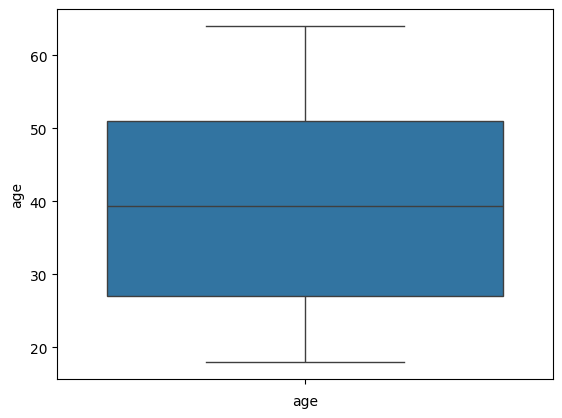

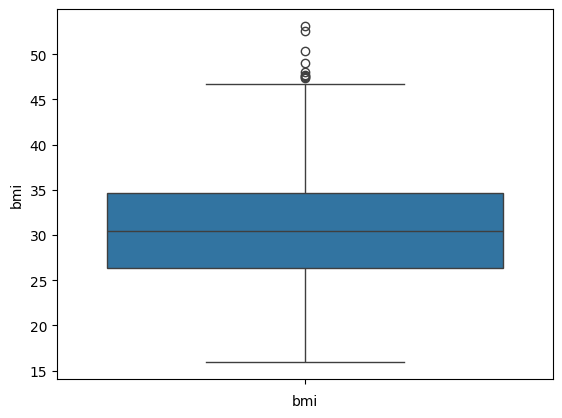

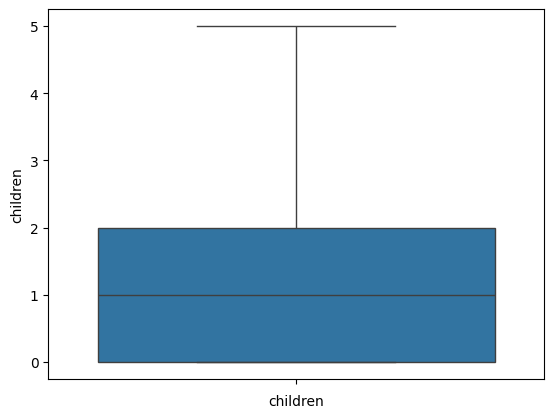

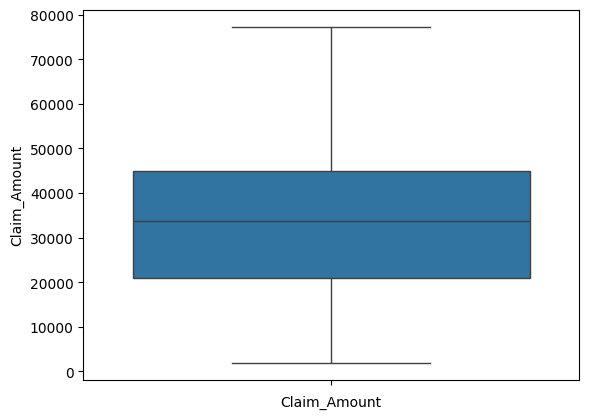

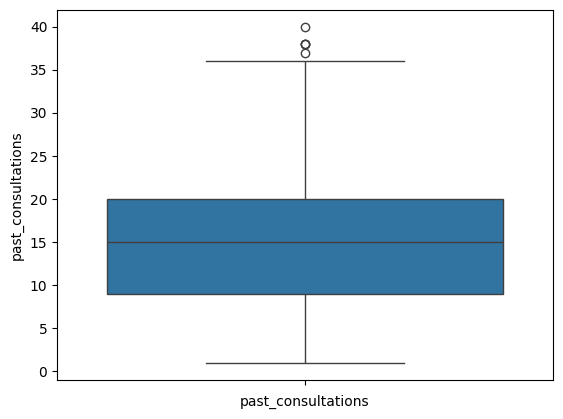

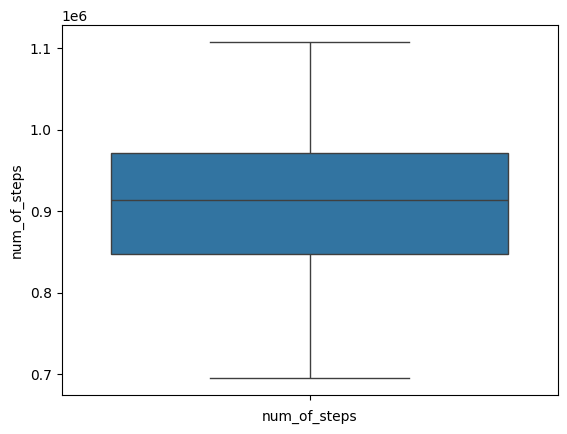

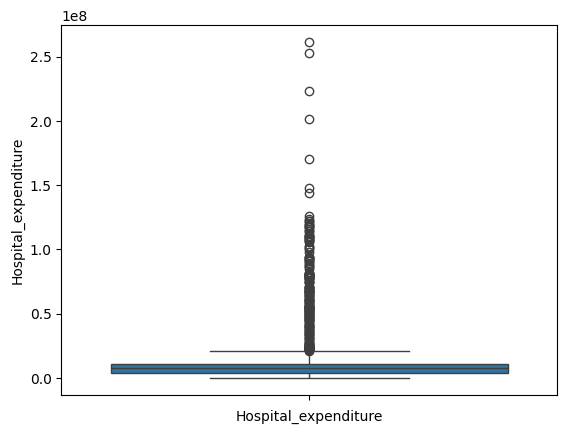

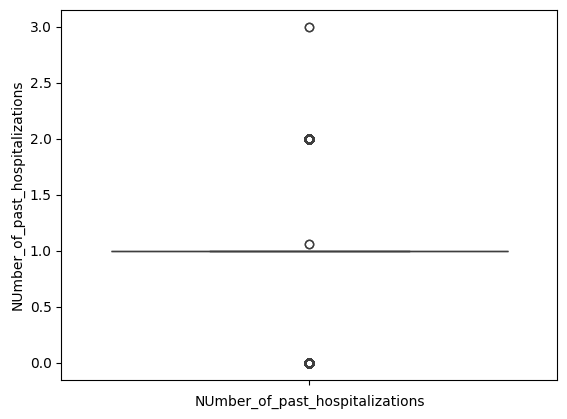

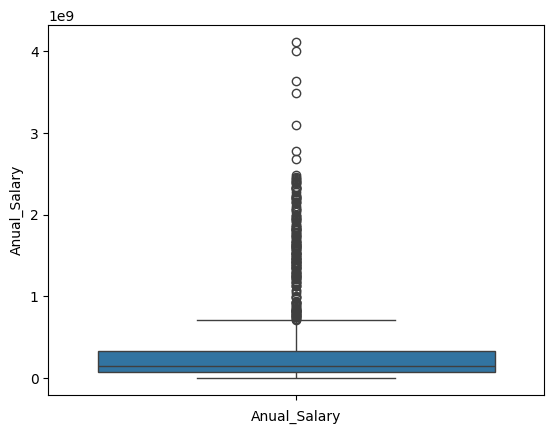

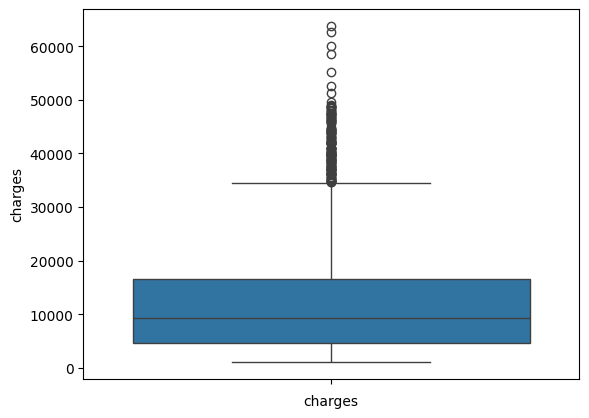

In [ ]:
# outliers visulization
for col in df.columns:
  if (df[col].dtype!='object'):
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [ ]:
# outliers removal
outliers =  ['bmi','past_consultations','Hospital_expenditure','NUmber_of_past_hospitalizations','Anual_Salary']
for col in outliers:
  q1  = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)

  iqr = q3-q1
  lb = q1 - (1.5*iqr)
  ub = q3 + (1.5*iqr)
  df = df[(df[col]>=lb) & (df[col]<=ub)]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 852 entries, 151 to 1024
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              852 non-null    float64
 1   sex                              852 non-null    object 
 2   bmi                              852 non-null    float64
 3   children                         852 non-null    float64
 4   smoker                           852 non-null    object 
 5   Claim_Amount                     852 non-null    float64
 6   past_consultations               852 non-null    float64
 7   num_of_steps                     852 non-null    float64
 8   Hospital_expenditure             852 non-null    float64
 9   NUmber_of_past_hospitalizations  852 non-null    float64
 10  Anual_Salary                     852 non-null    float64
 11  region                           852 non-null    object 
 12  charges                 

In [ ]:
# lable encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = le.fit_transform(df[col])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 852 entries, 151 to 1024
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              852 non-null    float64
 1   sex                              852 non-null    int64  
 2   bmi                              852 non-null    float64
 3   children                         852 non-null    float64
 4   smoker                           852 non-null    int64  
 5   Claim_Amount                     852 non-null    float64
 6   past_consultations               852 non-null    float64
 7   num_of_steps                     852 non-null    float64
 8   Hospital_expenditure             852 non-null    float64
 9   NUmber_of_past_hospitalizations  852 non-null    float64
 10  Anual_Salary                     852 non-null    float64
 11  region                           852 non-null    int64  
 12  charges                 

In [ ]:
# fit = learning something
# tranform = apply that learning

In [ ]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
151,25.0,1,27.550,0.0,0,39148.95495,10.0,780652.0,8.614147e+06,1.0,5.452601e+07,1,2523.16950
152,22.0,0,20.235,0.0,0,41547.52536,13.0,802627.0,2.491594e+05,1.0,1.671847e+07,1,2527.81865
153,25.0,1,35.625,0.0,0,39660.60193,12.0,770773.0,3.043323e+06,1.0,4.852694e+07,1,2534.39375
154,20.0,1,31.130,2.0,0,16032.87148,7.0,769255.0,1.599069e+06,1.0,2.441262e+07,2,2566.47070
155,21.0,0,17.400,1.0,0,31090.98977,21.0,778769.0,3.015365e+06,1.0,5.853579e+07,3,2585.26900
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,20.0,1,28.025,1.0,1,33996.01743,16.0,972338.0,1.064227e+07,1.0,3.374124e+08,1,17560.37975
1018,32.0,0,23.650,1.0,0,53840.22825,18.0,977689.0,7.081732e+06,1.0,3.390847e+08,2,17626.23951
1019,28.0,1,23.980,3.0,1,41686.19886,12.0,974518.0,8.679934e+06,1.0,3.225795e+08,2,17663.14420
1021,25.0,0,41.325,0.0,0,17100.29000,26.0,970038.0,8.933072e+06,1.0,3.353376e+08,0,17878.90068


splitting the data info x and y

splitting the data into training and testing

intelize the model

train the model

prediction

evalution

In [ ]:
x= df.iloc[:,:-1]
y= df['charges']

In [ ]:
x

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
151,25.0,1,27.550,0.0,0,39148.95495,10.0,780652.0,8.614147e+06,1.0,5.452601e+07,1
152,22.0,0,20.235,0.0,0,41547.52536,13.0,802627.0,2.491594e+05,1.0,1.671847e+07,1
153,25.0,1,35.625,0.0,0,39660.60193,12.0,770773.0,3.043323e+06,1.0,4.852694e+07,1
154,20.0,1,31.130,2.0,0,16032.87148,7.0,769255.0,1.599069e+06,1.0,2.441262e+07,2
155,21.0,0,17.400,1.0,0,31090.98977,21.0,778769.0,3.015365e+06,1.0,5.853579e+07,3
...,...,...,...,...,...,...,...,...,...,...,...,...
1017,20.0,1,28.025,1.0,1,33996.01743,16.0,972338.0,1.064227e+07,1.0,3.374124e+08,1
1018,32.0,0,23.650,1.0,0,53840.22825,18.0,977689.0,7.081732e+06,1.0,3.390847e+08,2
1019,28.0,1,23.980,3.0,1,41686.19886,12.0,974518.0,8.679934e+06,1.0,3.225795e+08,2
1021,25.0,0,41.325,0.0,0,17100.29000,26.0,970038.0,8.933072e+06,1.0,3.353376e+08,0


In [ ]:
y

,charges
151,2523.16950
152,2527.81865
153,2534.39375
154,2566.47070
155,2585.26900
...,...
1017,17560.37975
1018,17626.23951
1019,17663.14420
1021,17878.90068


In [ ]:
# x-train
# y-train
# x-test
# y-test(correct answers )
# y-pred(can be correct or incorrect)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test , y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
result = pd.DataFrame({'Actual':y_test,'Predicted':y_pred})

In [ ]:
result

,Actual,Predicted
686,9625.92000,9543.634380
719,10115.00885,10279.013730
339,4762.32900,5193.534153
953,14133.03775,12497.378384
650,9095.06825,8919.507758
...,...,...
605,8515.75870,9739.920527
559,7731.42710,7131.566728
705,9875.68040,10915.213136
843,11945.13270,11089.783026


In [ ]:
from sklearn.metrics import *
r_Score = r2_score(y_test,y_pred)
r_Score

0.9660153488236278

In [ ]:
r_Score *100

96.60153488236278

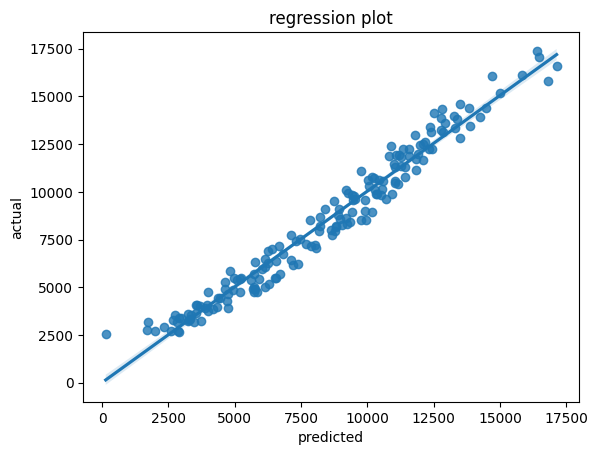

In [ ]:
sns.regplot(x=y_pred,y=y_test)
plt.title('regression plot')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()